#Project Overview
This project is a two-part data analysis and visualization assignment that explores wildfire activity in Australia using a dataset spanning from 2005 onwards. The goal is to uncover patterns in wildfire metrics through visual storytelling and build an interactive dashboard for user-driven exploration.

##Part 1: Analyzing Wildfire Activities in Australia
In this section, we perform exploratory data analysis (EDA) and create a variety of visualizations using Pandas, Matplotlib, Seaborn, and Folium to gain insights into wildfire behavior across seven regions in Australia.

 **Key Visualizations:**

Line Chart: Change in average estimated fire area over time.

Bar Plot: Mean estimated fire brightness across regions.

Pie Chart: Proportion of fire pixel counts across regions.

Histogram: Distribution of estimated fire brightness.

Scatter Plot: Correlation between radiative power and confidence.

Geospatial Map: Wildfire-affected regions visualized using Folium.

##Part 2: Interactive Dashboard with Dash & Plotly

This section focuses on building a dynamic dashboard using Dash and Plotly to allow users to select a Region and Year, and view customized charts.

**🎯 Dashboard Features:**

Dropdown & Radio Buttons: For selecting region and year.

Interactive Pie Chart: Displays monthly average estimated fire area.

Interactive Bar Chart: Shows monthly average fire pixel count.

Responsive Layout: Charts update in real-time based on user inputs.

##🗂 Dataset Overview

The dataset includes key wildfire indicators:

Region: One of seven Australian regions.

Date: UTC timestamp with 24-hour projections.

Estimated Fire Area: In km².

Fire Brightness & Radiative Power: In Kelvin and megawatts.

Confidence Scores: Mean, standard deviation, and variance.

Count: Daily count of high-confidence fire pixels.

Replaced: Indicator if data was replaced with higher-quality standard data.

##🚀 Technologies Used

Python

Pandas, Matplotlib, Seaborn, Folium

Dash, Plotly

In [2]:
%pip install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 folium
%pip install seaborn
%pip install folium


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
%matplotlib inline

###Importing Data

In [5]:
import pandas as pd

# Directly read the CSV from the URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
df = pd.read_csv(url)

In [7]:
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [11]:
#Column names
df.columns


Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [12]:
#data type
df.dtypes

,0
Region,object
Date,object
Estimated_fire_area,float64
Mean_estimated_fire_brightness,float64
Mean_estimated_fire_radiative_power,float64
Mean_confidence,float64
Std_confidence,float64
Var_confidence,float64
Count,int64
Replaced,object


In [13]:
import datetime as dt

df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month

In [14]:
#data type
df.dtypes

,0
Region,object
Date,object
Estimated_fire_area,float64
Mean_estimated_fire_brightness,float64
Mean_estimated_fire_radiative_power,float64
Mean_confidence,float64
Std_confidence,float64
Var_confidence,float64
Count,int64
Replaced,object


In [15]:
#Column names
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced', 'Year', 'Month'],
      dtype='object')

###TASK 1.1: Let's try to understand the change in average estimated fire area over time
(use pandas to plot)

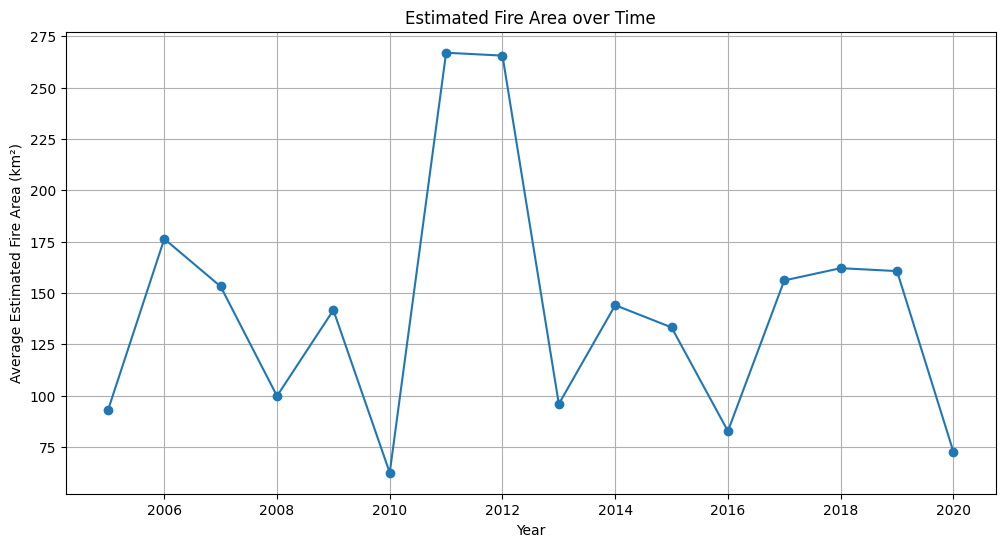

In [17]:
plt.figure(figsize=(12, 6))

# Grouping the data by 'Year' and calculating the mean of 'Estimated_fire_area'
df_new = df.groupby('Year')['Estimated_fire_area'].mean()

# Plotting the data
plt.plot(df_new.index, df_new.values, marker='o')  # Added marker for better visibility
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.grid(True)
plt.show()


###TASK 1.2: You can notice the peak in the plot between 2010 to 2013. Let's narrow down our finding, by plotting the estimated fire area for year grouped together with month.

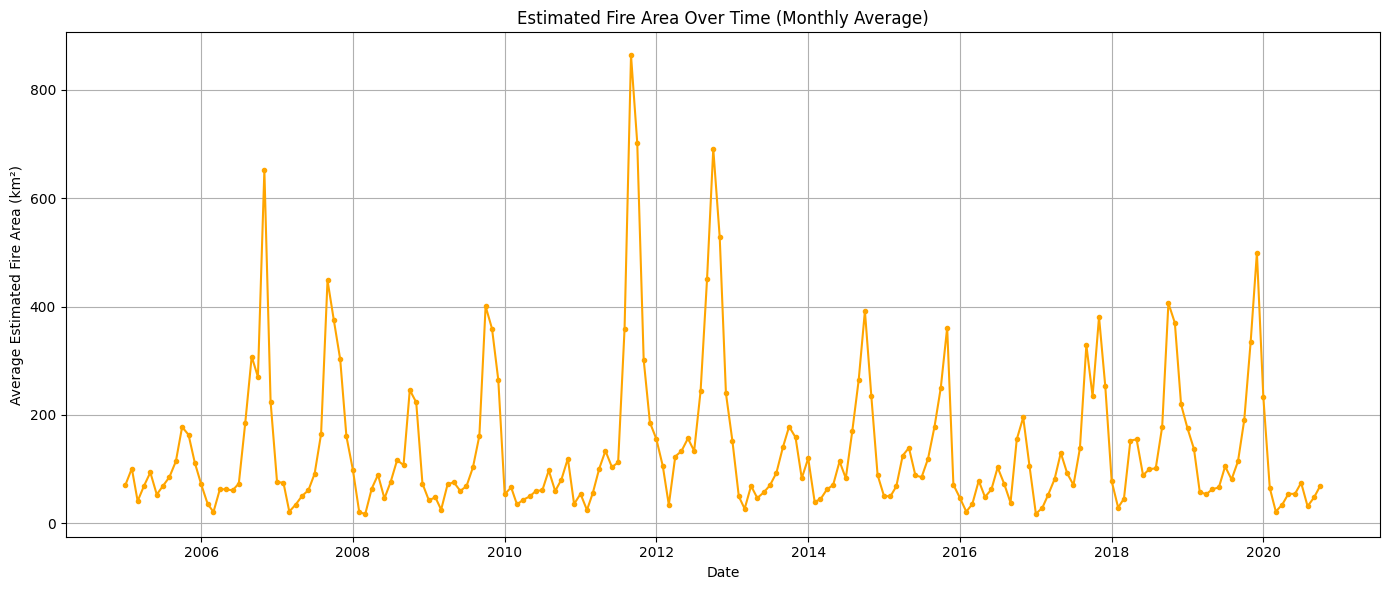

In [19]:
 # Group by 'Year' and 'Month' and calculate the mean of 'Estimated_fire_area'
df_new = df.groupby(['Year', 'Month'])['Estimated_fire_area'].mean()

# Reset index so Year and Month become columns
df_new = df_new.reset_index()

# Create a proper datetime column for x-axis
df_new['Date'] = pd.to_datetime(df_new[['Year', 'Month']].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_new['Date'], df_new['Estimated_fire_area'], color='orange', marker='.')
plt.xlabel('Date')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area Over Time (Monthly Average)')
plt.grid(True)
plt.tight_layout()
plt.show()

###TASK 1.3: Let's have an insight on the distribution of mean estimated fire brightness across the regions
use the functionality of seaborn to develop a barplot

In [20]:
df['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

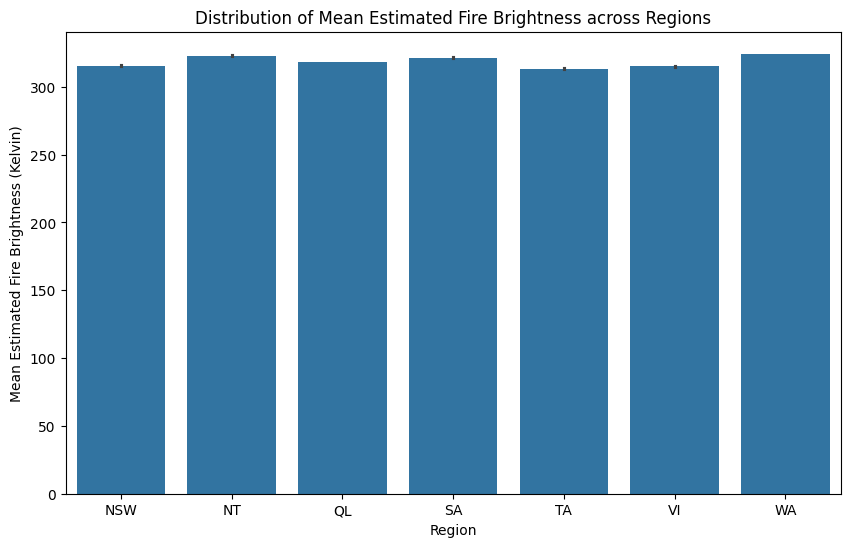

In [21]:
# Creating a bar plot using seaborn to visualize the distribution of mean estimated fire brightness across regions
plt.figure(figsize=(10, 6))
# Using seaborn's barplot function to create the plot
sns.barplot(data=df, x='Region', y='Mean_estimated_fire_brightness')
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

###TASK 1.4: Let's find the portion of count of pixels for presumed vegetation fires vary across regions
we will develop a pie chart for this

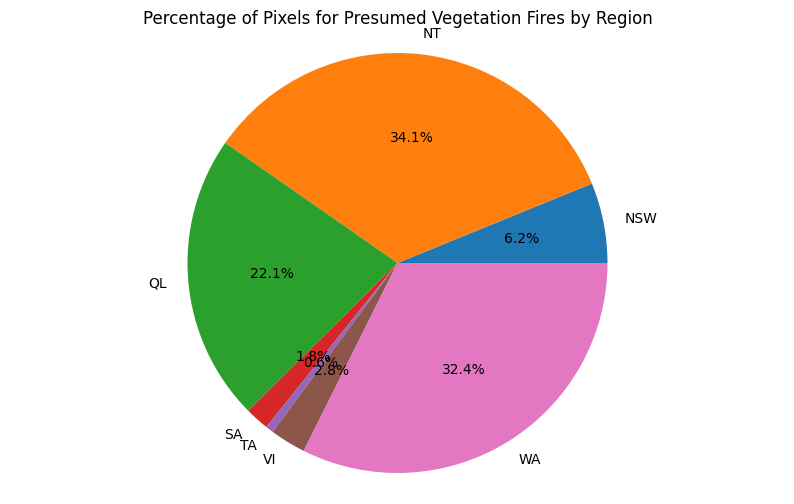

In [22]:
# Creating a pie chart to visualize the portion of count of pixels for presumed vegetation fires across regions
plt.figure(figsize=(10, 6))
# Grouping the data by region and summing the counts
region_counts = df.groupby('Region')['Count'].sum()
# Creating the pie chart using plt.pie function
# Labels are set to the region names, and autopct is used to display percentage
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.axis('equal')
plt.show()

###TASK 1.5: See the percentage on the pie is not looking so good as it is overlaped for Region SA, TA, VI

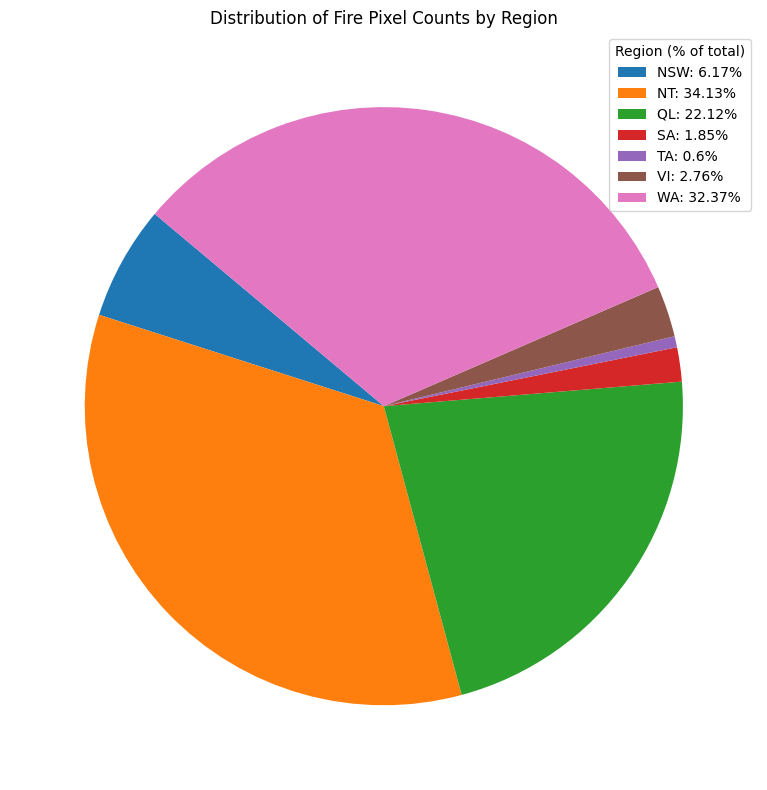

In [24]:
region_counts = df.groupby('Region')['Count'].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_counts, labels=None, startangle=140)  # Removed autopct
plt.title('Distribution of Fire Pixel Counts by Region')

# Custom legend with percentages
custom_labels = [(i, round(k / region_counts.sum() * 100, 2)) for i, k in zip(region_counts.index, region_counts)]
legend_labels = [f"{region}: {pct}%" for region, pct in custom_labels]
plt.legend(legend_labels, title="Region (% of total)", loc="best")

plt.tight_layout()
plt.show()

###TASK 1.6: Let's try to develop a histogram of the mean estimated fire brightness
Using Matplotlib to create the histogram

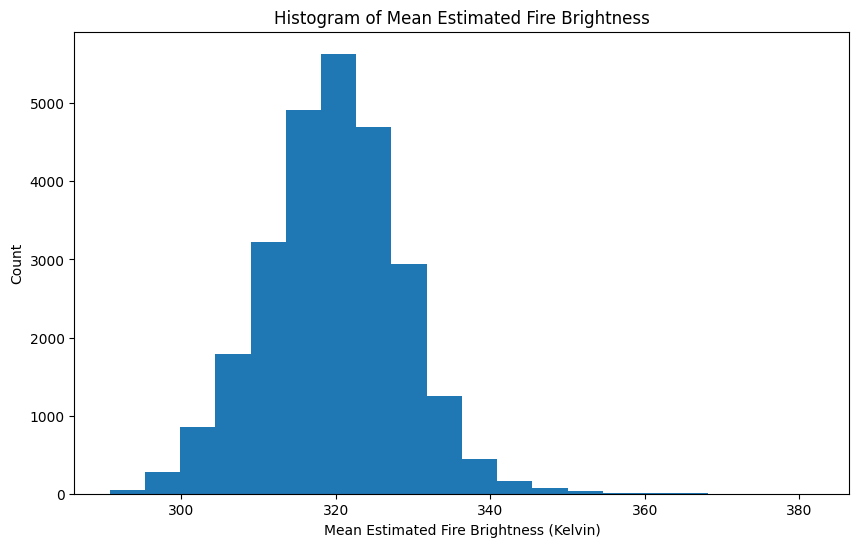

In [25]:
# Creating a histogram to visualize the distribution of mean estimated fire brightness
plt.figure(figsize=(10, 6))
# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
plt.hist(x=df['Mean_estimated_fire_brightness'], bins=20)
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Count')
plt.title('Histogram of Mean Estimated Fire Brightness')
plt.show()

###TASK 1.7: What if we need to understand the distribution of estimated fire brightness across regions? Let's use the functionality of seaborn and pass region as hue

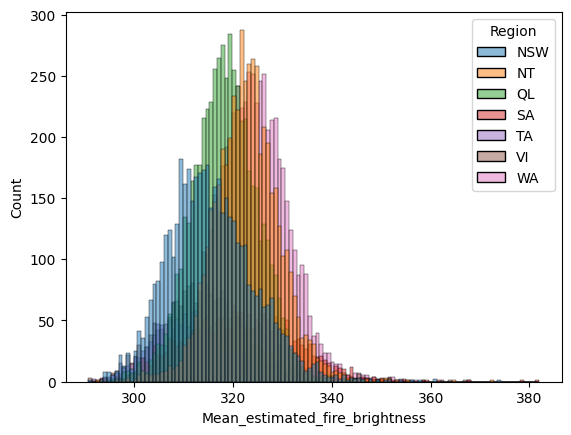

In [26]:
# Creating a histogram to visualize the distribution of mean estimated fire brightness across regions using Seaborn
# Using sns.histplot to create the histogram
# Specifying the DataFrame (data=df) and the column for the x-axis (x='Mean_estimated_fire_brightness')
# Adding hue='Region' to differentiate the distribution across regions
sns.histplot(data=df, x='Mean_estimated_fire_brightness', hue='Region')
plt.show()

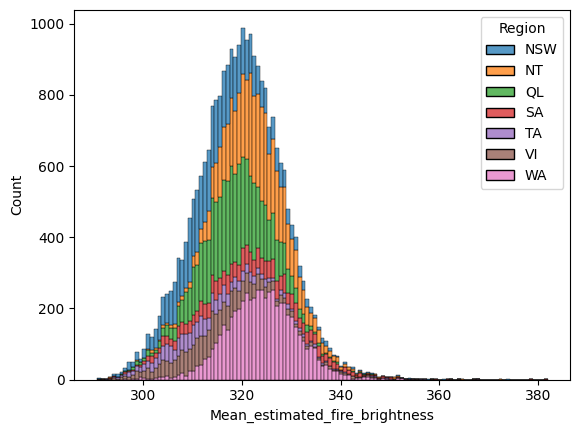

In [27]:
# Creating a stacked histogram to visualize the distribution of mean estimated fire brightness across regions using Seaborn
# Using sns.histplot to create the stacked histogram
# Specifying the DataFrame (data=df) and the column for the x-axis (x='Mean_estimated_fire_brightness')
# Adding hue='Region' to differentiate the distribution across regions
# Setting multiple='stack' to stack the histograms for different regions
sns.histplot(data=df, x='Mean_estimated_fire_brightness', hue='Region', multiple='stack')
plt.show()

###TASK 1.8: Let's try to find if there is any correlation between mean estimated fire radiative power and mean confidence level?

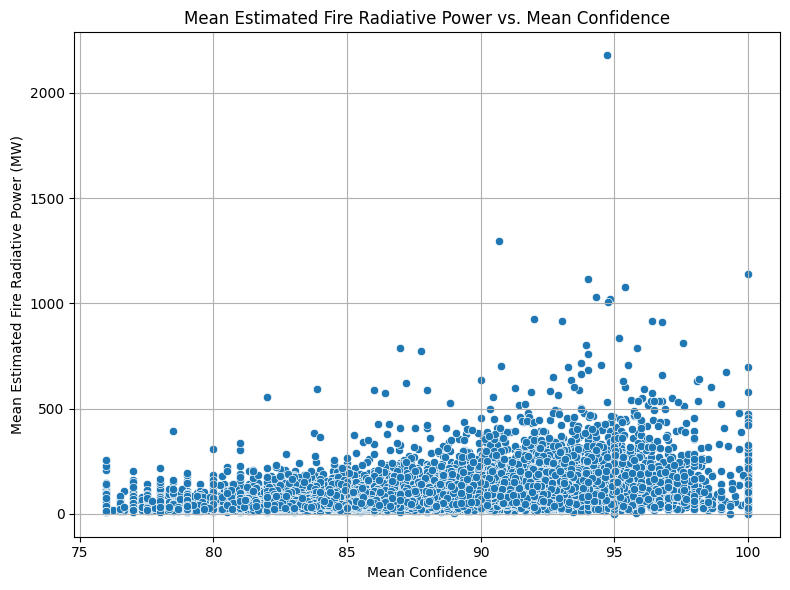

In [29]:
# Scatter plot showing relationship between confidence and radiative power
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Mean_confidence', y='Mean_estimated_fire_radiative_power')

plt.xlabel('Mean Confidence')
plt.ylabel('Mean Estimated Fire Radiative Power (MW)')
plt.title('Mean Estimated Fire Radiative Power vs. Mean Confidence')
plt.grid(True)
plt.tight_layout()
plt.show()

###TASK 1.9: Let's mark these seven regions on the Map of Australia using Folium

In [31]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411],
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg
# instantiate a feature group
aus_reg = folium.map.FeatureGroup()

# Create a Folium map centered on Australia
Aus_map = folium.Map(location=[-25, 135], zoom_start=4)

# loop through the region and add to feature group
for lat, lng, lab in zip(reg.Lat, reg.Lon, reg.region):
    aus_reg.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            popup=lab,
            radius=5, # define how big you want the circle markers to be
            color='red',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6
        )
    )

# add incidents to map
Aus_map.add_child(aus_reg)

#Part 2: Interactive Dashboard with Dash & Plotly





In [34]:
!pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 20.4 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [5]:
import pandas as pd
import dash
from dash import html, dcc
from dash.dependencies import Input, Output, State
import plotly.express as px
import datetime as dt

# Create app
app = dash.Dash(__name__)
app.config.suppress_callback_exceptions = True

# Read the wildfire data into pandas dataframe
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv')

# Extract year and month from the date column
df['Month'] = pd.to_datetime(df['Date']).dt.month_name()  # used for month names
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Layout Section of Dash
# Task 2.1 Add the Title to the Dashboard
app.layout = html.Div(children=[
    html.H1("Australian Wildfire Dashboard", style={'textAlign': 'center'}),

    # TASK 2.2: Add the radio items and a dropdown right below the first inner division
    html.Div([
        # First inner division for adding radio items
        html.Div([
            html.H2("Select Region:"),
            dcc.RadioItems([
                {"label": "New South Wales", "value": "NSW"},
                {"label": "Queensland", "value": "QLD"},
                {"label": "South Australia", "value": "SA"},
                {"label": "Tasmania", "value": "TAS"},
                {"label": "Victoria", "value": "VIC"},
                {"label": "Western Australia", "value": "WA"},
                {"label": "Northern Territory", "value": "NT"}
            ], value="NSW", id='region-selector', inline=True),
        ]),

        # Dropdown to select year
        html.Div([
            html.H2('Select Year:', style={'marginTop': '20px'}),
            dcc.Dropdown(
                id='year-selector',
                options=[{'label': str(y), 'value': y} for y in sorted(df['Year'].unique())],
                value=df['Year'].min()
            )
        ]),

        # Second inner division for adding 2 inner divisions for output graphs
        html.Div([
            html.Div([], id='output-container-pie', style={'width': '48%', 'display': 'inline-block'}),
            html.Div([], id='output-container-bar', style={'width': '48%', 'display': 'inline-block'})
        ], style={'marginTop': '30px'})
    ])
])

# TASK 2.4: Add the Output and Input components inside the app.callback decorator.
@app.callback(
    [Output(component_id='output-container-pie', component_property='children'),
     Output(component_id='output-container-bar', component_property='children')],
    [Input(component_id='region-selector', component_property='value'),
     Input(component_id='year-selector', component_property='value')]
)

# TASK 2.5: Add the callback function.
def reg_year_display(input_region, input_year):
    region_data = df[df['Region'] == input_region]
    y_r_data = region_data[region_data['Year'] == input_year]

    # Plot one - Monthly Average Estimated Fire Area
    est_data = y_r_data.groupby('Month')['Estimated_fire_area'].mean().reset_index()
    fig1 = px.pie(est_data, names='Month', values='Estimated_fire_area',
                  title="{}: Monthly Average Estimated Fire Area in {}".format(input_region, input_year))

    # Plot two - Monthly Average Count of Pixels for Presumed Vegetation Fires
    veg_data = y_r_data.groupby('Month')['Count'].mean().reset_index()
    fig2 = px.bar(veg_data, x='Month', y='Count',
                  title='{}: Avg. Count of Pixels for Presumed Vegetation Fires in {}'.format(input_region, input_year),
                  labels={'Count': 'Average Pixel Count'})

    return [dcc.Graph(figure=fig1), dcc.Graph(figure=fig2)]


if __name__ == '__main__':
    app.run()


<IPython.core.display.Javascript object>

###TASK 2.1: Add title to the dashboard

In [36]:
html.H1('Australia Wildfire Dashboard',
                                style={'textAlign': 'center', 'color': '#503D36',
                                'font-size': 26}),

(H1(children='Australia Wildfire Dashboard', style={'textAlign': 'center', 'color': '#503D36', 'font-size': 26}),)

###TASK 2.2: Add the radio items and a dropdown right below the first inner division.

In [38]:
html.Div([
    html.H2('Select Region:', style={'margin-right': '2em'}),
    dcc.RadioItems(
        options=[
            {'label': 'New South Wales', 'value': 'NSW'},
            {'label': 'Queensland', 'value': 'QL'},
            {'label': 'South Australia', 'value': 'SA'},
            {'label': 'Tasmania', 'value': 'TA'},
            {'label': 'Victoria', 'value': 'VI'},
            {'label': 'Western Australia', 'value': 'WA'}
        ],
        value='NSW',
        id='region',
        inline=True
    )
]),

html.Div([
    html.H2('Select Year:', style={'margin-right': '2em'}),
    dcc.Dropdown(
        options=[{'label': str(year), 'value': year} for year in sorted(df['Year'].unique())],
        value=2005,
        id='year'
    )
])


Div([H2(children='Select Year:', style={'margin-right': '2em'}), Dropdown(options=[{'label': '2005', 'value': np.int32(2005)}, {'label': '2006', 'value': np.int32(2006)}, {'label': '2007', 'value': np.int32(2007)}, {'label': '2008', 'value': np.int32(2008)}, {'label': '2009', 'value': np.int32(2009)}, {'label': '2010', 'value': np.int32(2010)}, {'label': '2011', 'value': np.int32(2011)}, {'label': '2012', 'value': np.int32(2012)}, {'label': '2013', 'value': np.int32(2013)}, {'label': '2014', 'value': np.int32(2014)}, {'label': '2015', 'value': np.int32(2015)}, {'label': '2016', 'value': np.int32(2016)}, {'label': '2017', 'value': np.int32(2017)}, {'label': '2018', 'value': np.int32(2018)}, {'label': '2019', 'value': np.int32(2019)}, {'label': '2020', 'value': np.int32(2020)}], value=2005, id='year')])

###TASK 2.3: Add two empty divisions for output inside the next inner division.

In [39]:
html.Div([ ], id='plot1'),
html.Div([ ], id='plot2')

Div(children=[], id='plot2')

###TASK 2.4: Add the Ouput and input components inside the app.callback decorator.

###TASK 2.5: Add the callback function.

In [ ]:
!pip install jupyter-dash==0.4.2
!pip install dash


In [1]:
# Step 1: Install compatible versions
!pip install jupyter-dash==0.4.2 dash==2.12.1

# Step 2: Restart the runtime manually here (Runtime > Restart Runtime), then rerun from here:

# Step 3: Import libraries
from jupyter_dash import JupyterDash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

# Sample DataFrame (replace this with your actual wildfire dataset)
# Just to demonstrate, here’s a simplified placeholder
data = {
    'Region': ['NSW', 'NSW', 'QL', 'QL', 'VI', 'VI'],
    'Year': [2005, 2005, 2006, 2006, 2005, 2006],
    'Month': ['Jan', 'Feb', 'Jan', 'Feb', 'Jan', 'Feb'],
    'Estimated_fire_area': [100, 150, 200, 250, 300, 350],
    'Count': [10, 20, 15, 25, 30, 35]
}
df = pd.DataFrame(data)

# Step 4: Create the app
app = JupyterDash(__name__)
app.layout = html.Div([
    html.H1('Australia Wildfire Dashboard', style={'textAlign': 'center', 'color': '#503D36', 'font-size': 26}),

    html.Div([
        html.H2('Select Region:', style={'margin-right': '2em'}),
        dcc.RadioItems(
            options=[
                {'label': 'New South Wales', 'value': 'NSW'},
                {'label': 'Queensland', 'value': 'QL'},
                {'label': 'South Australia', 'value': 'SA'},
                {'label': 'Tasmania', 'value': 'TA'},
                {'label': 'Victoria', 'value': 'VI'},
                {'label': 'Western Australia', 'value': 'WA'}
            ],
            value='NSW',
            id='region',
            inline=True
        )
    ]),

    html.Div([
        html.H2('Select Year:', style={'margin-right': '2em'}),
        dcc.Dropdown(
            options=[{'label': str(year), 'value': year} for year in sorted(df['Year'].unique())],
            value=2005,
            id='year'
        )
    ]),

    html.Div([], id='plot1'),
    html.Div([], id='plot2')
])

# Step 5: Define callback
@app.callback(
    [Output('plot1', 'children'),
     Output('plot2', 'children')],
    [Input('region', 'value'),
     Input('year', 'value')]
)
def update_graphs(input_region, input_year):
    region_data = df[df['Region'] == input_region]
    y_r_data = region_data[region_data['Year'] == input_year]

    est_data = y_r_data.groupby('Month')['Estimated_fire_area'].mean().reset_index()
    fig1 = px.pie(est_data, names='Month', values='Estimated_fire_area',
                  title=f"{input_region} : Monthly Avg Estimated Fire Area in {input_year}")

    veg_data = y_r_data.groupby('Month')['Count'].mean().reset_index()
    fig2 = px.bar(veg_data, x='Month', y='Count',
                  title=f"{input_region} : Avg Count of Pixels for Fires in {input_year}")

    return [dcc.Graph(figure=fig1), dcc.Graph(figure=fig2)]

# Step 6: Run the app
app.run_server(debug=True)


/usr/local/lib/python3.11/dist-packages/dash/dash.py:516: UserWarning: JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.
  warnings.warn(


<IPython.core.display.Javascript object>

Dash app running on:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>